# Modelado ML Telco Customer Churn
**Proyecto:** Predicción de Abandono de Clientes con ML + LLM  

## Configuración

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, roc_curve, confusion_matrix
)
from xgboost import XGBClassifier

# Semilla fija para reproducibilidad en todos los experimentos
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

FIG_DIR = '../data/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

print('Configuración lista.')

Configuración lista.


## Carga de datos y preprocesamiento

In [12]:
df = pd.read_csv('../data/telco_clean.csv')

# Eliminar columna de ID, no aporta información predictiva
df = df.drop(columns=['customerID'])

# Variable objetivo: convertir Yes/No a 1/0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Codificación de variables categóricas con One-Hot Encoding
# drop_first=True evita multicolinealidad (dummy variable trap)
df_encoded = pd.get_dummies(df, drop_first=True)

print(f'Shape después del encoding: {df_encoded.shape}')
print(f'Variables del modelo: {df_encoded.columns.tolist()}')

Shape después del encoding: (7043, 31)
Variables del modelo: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [13]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Split train/test ANTES de cualquier transformación para evitar data leakage
# El modelo nunca ve los datos de test durante el entrenamiento ni el tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Churn en train: {y_train.mean():.2%} | Churn en test: {y_test.mean():.2%}')

Train: 5634 filas | Test: 1409 filas
Churn en train: 26.54% | Churn en test: 26.54%


## Baseline: Regresión Logística

In [14]:
# El baseline establece el piso mínimo de rendimiento que debe superar el modelo principal
# class_weight='balanced' corrige el desbalance de clases (~26% Churn) automáticamente
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

auc_base = roc_auc_score(y_test, y_prob_base)
f1_base  = f1_score(y_test, y_pred_base)

print('Regresión Logística (Baseline)')
print('-' * 40)
print(f'AUC-ROC : {auc_base:.4f}')
print(f'F1 Score: {f1_base:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['No Churn', 'Churn']))

Regresión Logística (Baseline)
----------------------------------------
AUC-ROC : 0.8414
F1 Score: 0.6164

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Modelo principal: XGBoost

In [15]:
# XGBoost maneja internamente el desbalance con scale_pos_weight
# scale_pos_weight = negativos / positivos para darle más peso a la clase minoritaria
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight calculado: {scale:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)

print()
print('XGBoost (Modelo principal)')
print('-' * 40)
print(f'AUC-ROC : {auc_xgb:.4f}')
print(f'F1 Score: {f1_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

scale_pos_weight calculado: 2.77

XGBoost (Modelo principal)
----------------------------------------
AUC-ROC : 0.8393
F1 Score: 0.6285

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



## Tabla comparativa de modelos

In [16]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

resultados = pd.DataFrame({
    'Modelo':    ['Regresión Logística (Baseline)', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, y_pred_base), accuracy_score(y_test, y_pred_xgb)],
    'F1 Score':  [f1_base,  f1_xgb],
    'AUC-ROC':   [auc_base, auc_xgb],
    'Precision': [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_base),    recall_score(y_test, y_pred_xgb)]
})

resultados = resultados.set_index('Modelo').round(4)
print('Tabla comparativa de modelos:')
print(resultados.to_string())

mejora_auc = (auc_xgb - auc_base) / auc_base * 100
mejora_f1  = (f1_xgb  - f1_base)  / f1_base  * 100
print(f'\nXGBoost mejora el baseline en AUC-ROC: +{mejora_auc:.1f}% | F1: +{mejora_f1:.1f}%')

Tabla comparativa de modelos:
                                Accuracy  F1 Score  AUC-ROC  Precision  Recall
Modelo                                                                        
Regresión Logística (Baseline)    0.7402    0.6164   0.8414     0.5069  0.7861
XGBoost                           0.7516    0.6285   0.8393     0.5211  0.7914

XGBoost mejora el baseline en AUC-ROC: +-0.2% | F1: +2.0%


## Figura 6: Curvas ROC (Baseline vs XGBoost)

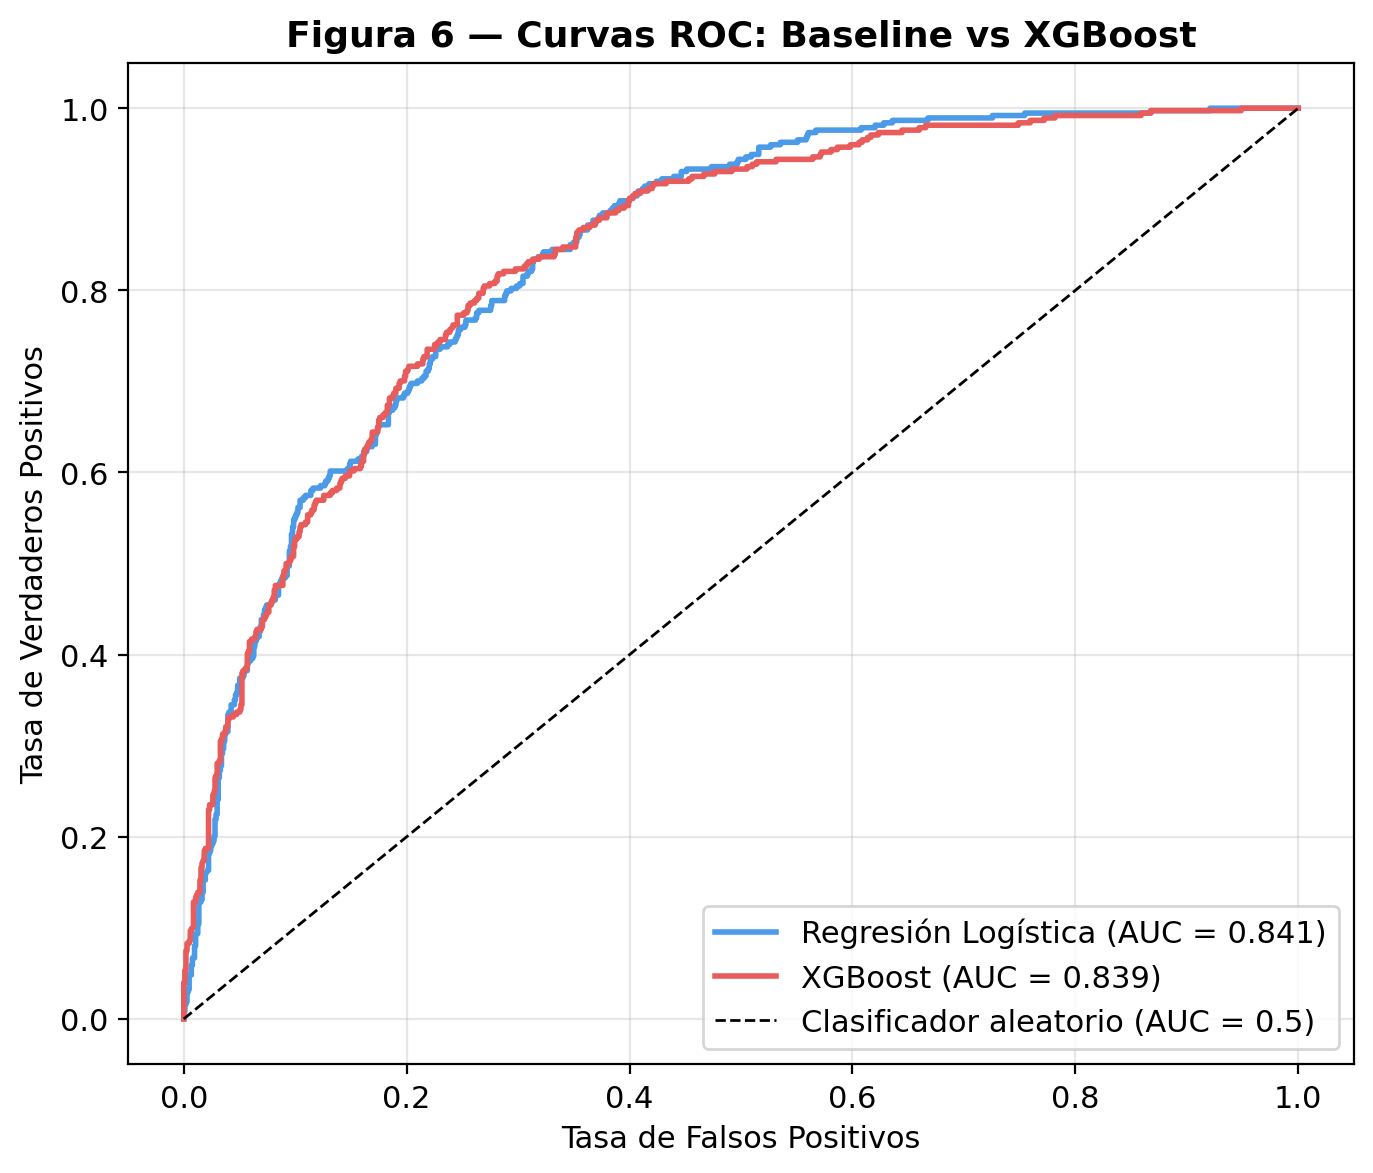

In [17]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_base, tpr_base, color='#4C9BE8', linewidth=2,
        label=f'Regresión Logística (AUC = {auc_base:.3f})')
ax.plot(fpr_xgb,  tpr_xgb,  color='#E85C5C', linewidth=2,
        label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Línea de referencia: clasificador aleatorio
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.5)')

ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Figura 6 — Curvas ROC: Baseline vs XGBoost', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig6_roc_curves.png')
plt.show()

## Figura 7: SHAP (Importancia de variables)

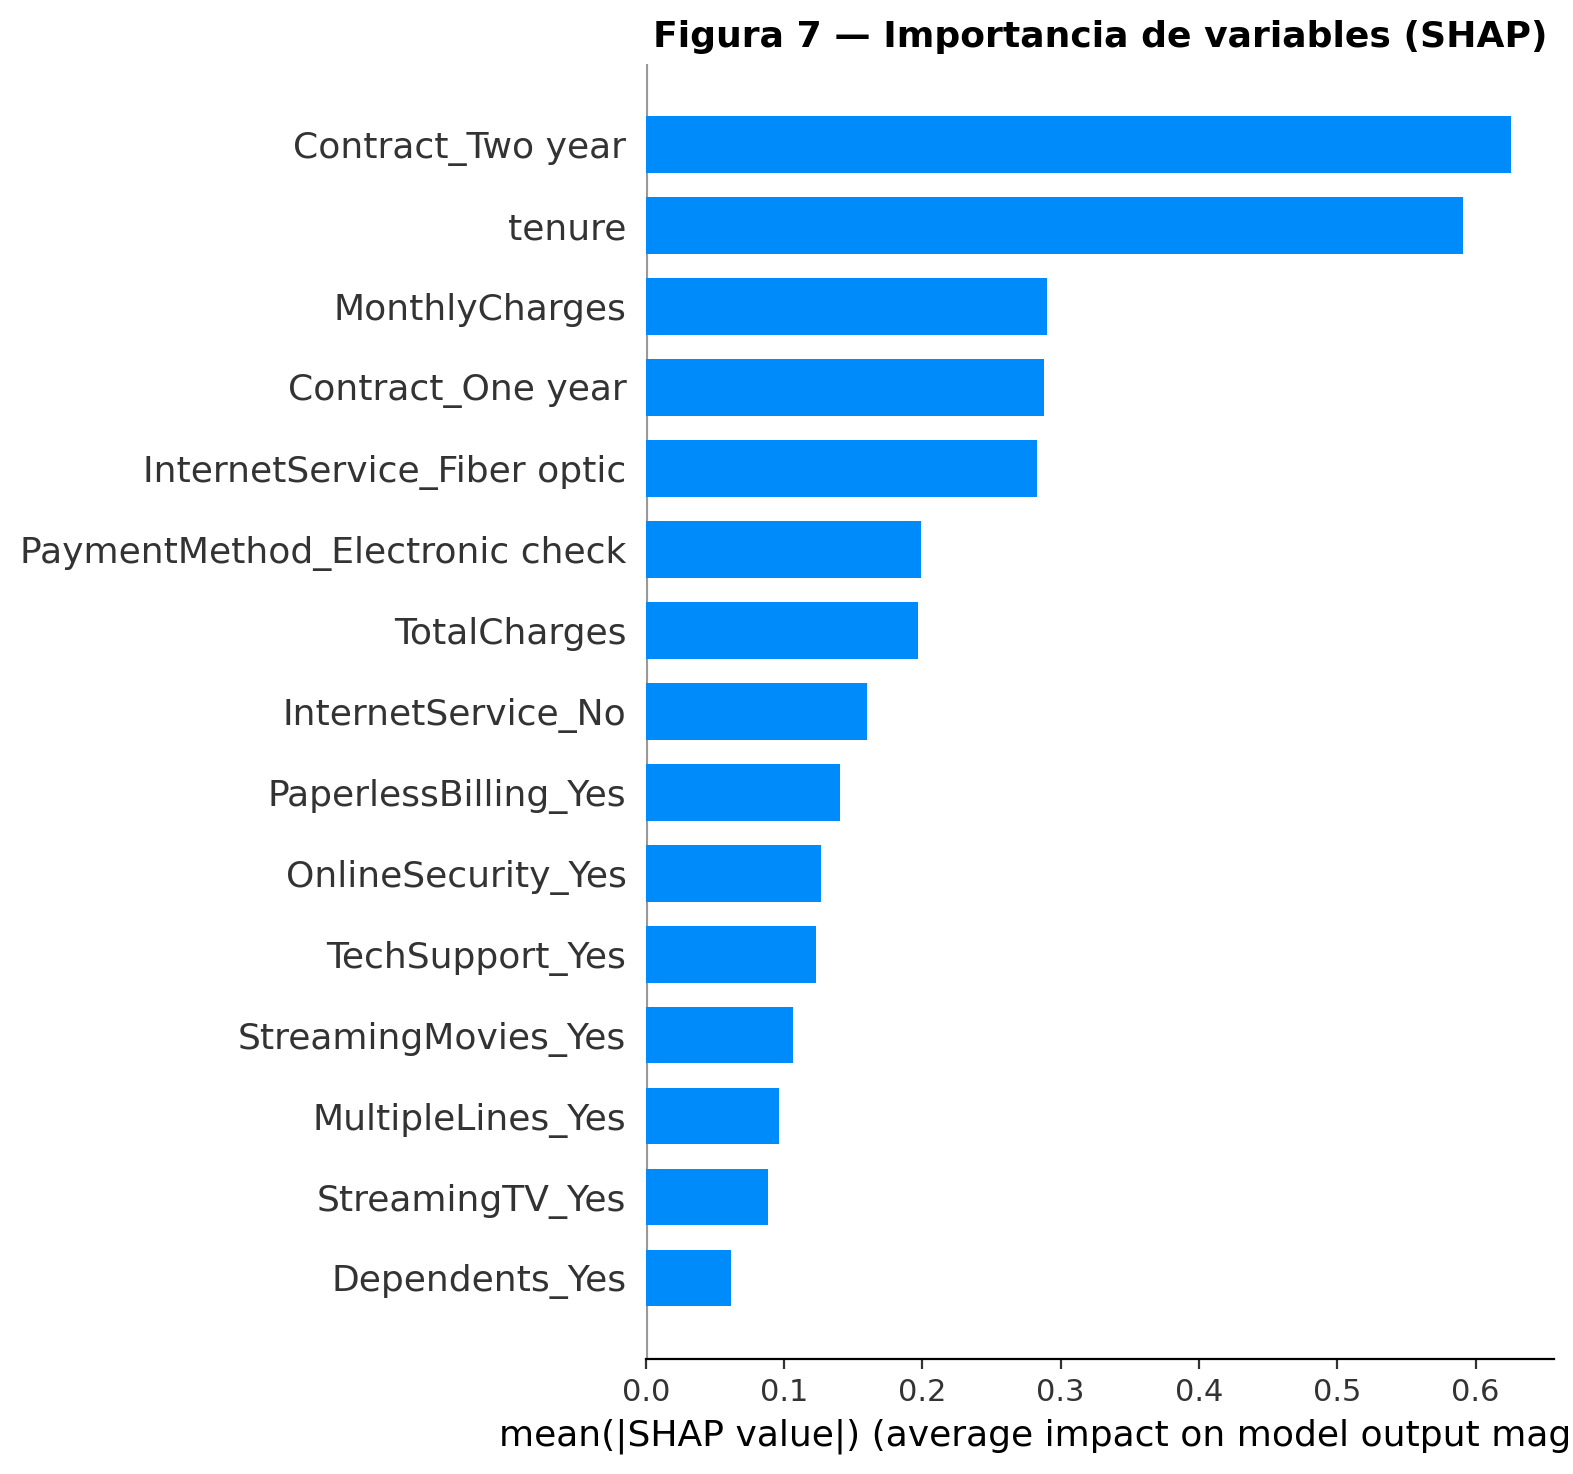

In [18]:
# SHAP explica cuánto aporta cada variable a la predicción de cada cliente
# Se usa TreeExplainer porque XGBoost es un modelo basado en árboles
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Figura 7 — Importancia de variables (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7_shap_importance.png')
plt.show()

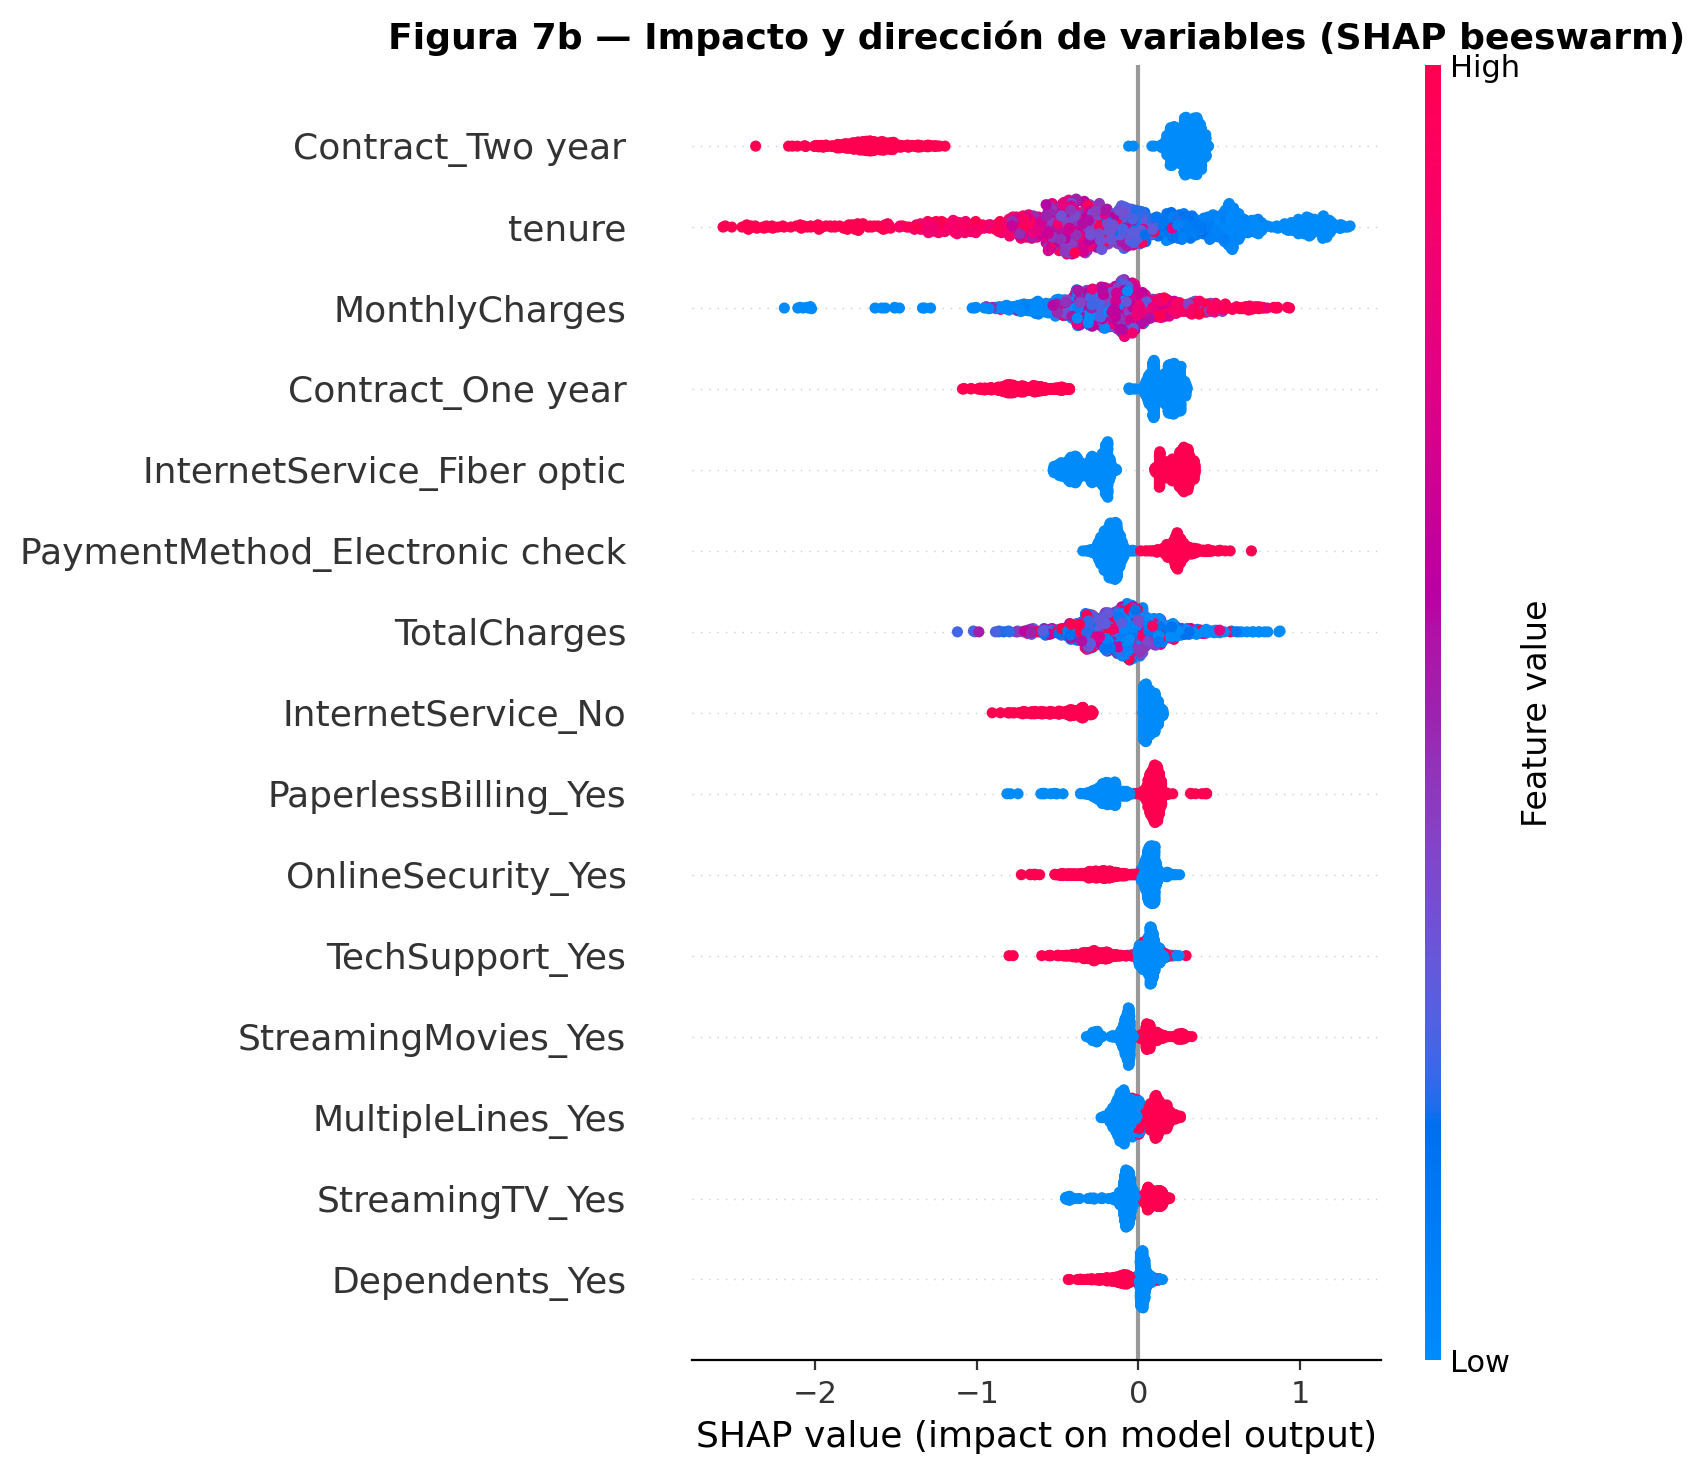

In [19]:
# SHAP beeswarm: muestra dirección e intensidad del impacto de cada variable
# Rojo = valor alto de la variable, Azul = valor bajo
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title('Figura 7b — Impacto y dirección de variables (SHAP beeswarm)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7b_shap_beeswarm.png')
plt.show()

## Guardar modelo y features para la app

In [20]:
import joblib

os.makedirs('../models', exist_ok=True)

# Guardar el modelo XGBoost entrenado
joblib.dump(xgb_model, '../models/xgb_churn_model.pkl')

# Guardar la lista de columnas para que la app use exactamente las mismas
joblib.dump(list(X_train.columns), '../models/feature_columns.pkl')

print('Modelo guardado en: models/xgb_churn_model.pkl')
print('Columnas guardadas en: models/feature_columns.pkl')
print(f'\nResumen final:')
print(f'  Baseline AUC-ROC : {auc_base:.4f}')
print(f'  XGBoost  AUC-ROC : {auc_xgb:.4f}')
print(f'  Baseline F1      : {f1_base:.4f}')
print(f'  XGBoost  F1      : {f1_xgb:.4f}')

Modelo guardado en: models/xgb_churn_model.pkl
Columnas guardadas en: models/feature_columns.pkl

Resumen final:
  Baseline AUC-ROC : 0.8414
  XGBoost  AUC-ROC : 0.8393
  Baseline F1      : 0.6164
  XGBoost  F1      : 0.6285
